--- INITIATING LIVE TELEMETRY PREDICTION ---

[SYSTEM] Image processed successfully.
[SYSTEM] Constructor Identified: Williams F1 car
[SYSTEM] Confidence Level: 99.78%


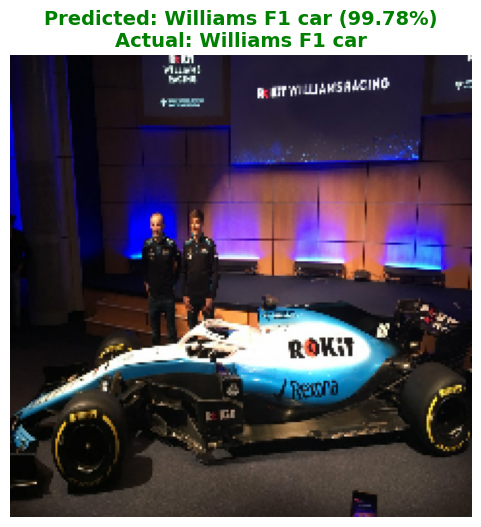

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("--- INITIATING LIVE TELEMETRY PREDICTION ---")

# Take one random batch from the validation track
for images, labels in val_dataset.shuffle(100).take(1):

    # Select the first car in the batch
    test_image = images[0]
    true_label = labels[0].numpy()

    # Preprocess the image for the ResNet-50 engine (Expand to batch of 1)
    img_array = tf.expand_dims(test_image, 0)

    # Execute the prediction
    predictions = model2.predict(img_array, verbose=0) # verbose=0 keeps the output clean
    predicted_class_index = np.argmax(predictions)

    # Extract the constructor names
    true_team = class_names[true_label]
    predicted_team = class_names[predicted_class_index]
    confidence = np.max(predictions) * 100

    # Display the visual telemetry
    plt.figure(figsize=(6, 6))
    plt.imshow(test_image.numpy().astype("uint8"))
    plt.axis("off")

    # Turn text green if correct, red if the model crashes
    title_color = 'green' if true_team == predicted_team else 'red'

    plt.title(f"Predicted: {predicted_team} ({confidence:.2f}%)\nActual: {true_team}",
              color=title_color, fontsize=14, fontweight='bold')

    print(f"\n[SYSTEM] Image processed successfully.")
    print(f"[SYSTEM] Constructor Identified: {predicted_team}")
    print(f"[SYSTEM] Confidence Level: {confidence:.2f}%")

    plt.show()
    break # We only need one live prediction for the camera